# Cải tiến TransUNet — Hướng 1: Attention Gate cho Skip-Connection

**Tên mô hình mới: `TransUNet_AttnSkip`**

## Ý tưởng
Bài báo TransUNet (Mục 4.4) có nhận xét: *"As an interesting study, we apply additive
Transformers in the skip-connections ... leads to a performance boost of 1.4% DSC"*.

Trong code gốc, skip-connection chỉ là phép **concatenate thô** (`torch.cat`) giữa feature
map của CNN encoder (ResNet-50) và feature của decoder. Feature CNN ở các tầng nông mang
theo **nhiều nhiễu / background** không liên quan, làm biên dự đoán bị "tràn" → **HD95 cao**.

## Giải pháp
Chèn **3 lớp Attention Gate** (lấy từ *Attention U-Net*, Reference [10] trong TransUNet) vào
đúng 3 nhánh skip-connection — tại scale **1/2 (112×112, 64ch)**, **1/4 (56×56, 256ch)**,
**1/8 (28×28, 512ch)** — **trước khi concatenate** với decoder.

Attention Gate dùng feature decoder (coarse, ngữ nghĩa cao) làm **gating signal** để tạo
**hệ số chú ý α ∈ [0,1]** cho từng pixel của skip feature, qua đó **lọc bỏ vùng background dư
thừa** và chỉ giữ lại vùng biên cơ quan liên quan nhất.

\[
\hat{x}_{skip} = x_{skip} \cdot \sigma\big(\psi(\mathrm{ReLU}(W_g\,g + W_x\,x_{skip}))\big)
\]

→ Kỳ vọng cải thiện trực tiếp **HD95** (sai lệch biên) và DSC.

## Lưu ý
- Notebook chạy trên **Google Colab (GPU)**.
- Dữ liệu: dùng lại bộ **Synapse** (đã khảo sát ở `data.ipynb`). Cell setup chỉ tải dữ liệu
  về môi trường Colab để train, **không làm lại bước phân tích data**.
- Mô hình baseline (TransUNet, U-Net) lấy số liệu từ `demo.ipynb` để so sánh.

## 1. Thiết lập môi trường Colab
Cài thư viện, clone repo TransUNet, tải dữ liệu Synapse từ Kaggle và trọng số ViT pretrained.
(Giống bước chuẩn bị trong `demo.ipynb` — chỉ để Colab có đủ dữ liệu chạy.)

In [1]:
# === 1. INSTALL ===
!pip install -q ml-collections medpy SimpleITK tensorboardX h5py scipy matplotlib kaggle

# === 2. CLONE REPO ===
!rm -rf /content/TransUNet
!git clone https://github.com/Beckschen/TransUNet.git

# === 3. KAGGLE CREDENTIALS ===
import os, shutil
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(b'{"username":"ynzboyvt","key":"KGAT_e1129cdba4fc46f3eb3dfdfb0c7b7f9a"}')
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# === 4. DOWNLOAD DATA (Synapse - giong data.ipynb) ===
!kaggle datasets download -d dogcdt/synapse -p /content/synapse_zip
!unzip -q -o /content/synapse_zip/*.zip -d /content/synapse_temp

# === 5. MOVE DATA ===
for folder in ['train_npz', 'test_vol_h5']:
    src = f'/content/synapse_temp/Synapse/{folder}'
    dst = f'/content/data/Synapse/{folder}'
    os.makedirs(dst, exist_ok=True)
    for fname in os.listdir(src):
        shutil.move(os.path.join(src, fname), os.path.join(dst, fname))
!rm -rf /content/synapse_zip /content/synapse_temp

# === 6. VIT PRETRAINED WEIGHTS ===
os.makedirs('/content/model/vit_checkpoint/imagenet21k', exist_ok=True)
!wget -q https://storage.googleapis.com/vit_models/imagenet21k/R50+ViT-B_16.npz \
    -O /content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz

# === 7. FIX CONFIG PATH ===
cfg = '/content/TransUNet/networks/vit_seg_configs.py'
with open(cfg, 'r') as f: txt = f.read()
txt = txt.replace("'../model/vit_checkpoint/imagenet21k/", "'/content/model/vit_checkpoint/imagenet21k/")
with open(cfg, 'w') as f: f.write(txt)

# === 8. CHECK ===
t = len(os.listdir('/content/data/Synapse/train_npz'))
e = len(os.listdir('/content/data/Synapse/test_vol_h5'))
wf = '/content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz'
w = os.path.exists(wf) and os.path.getsize(wf) > 1_000_000
gpu = !nvidia-smi --query-gpu=name --format=csv,noheader
print(f"\nGPU: {gpu[0] if gpu else 'NONE!'}")
print(f"Train: {t} files {'OK' if t>0 else 'MISSING'}")
print(f"Test:  {e} files {'OK' if e>0 else 'MISSING'}")
print(f"ViT:   {'OK' if w else 'MISSING'}")
print(f"\n{'SAN SANG TRAIN!' if t>0 and e>0 and w else 'CON THIEU!'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.1 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 11.75 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Dataset URL: https://www.kaggle.com/datasets/dogcdt/synapse
License(s): unknown
100% 607M/607M [00:33<00:00, 18.9MB/s]


GPU: NVIDIA A100-SXM4-80GB
Train: 2211 files OK
Test:  12 files OK
ViT:   OK

SAN SANG TRAIN!


In [2]:
%cd /content/TransUNet
# Tao __init__.py cho cac package de import duoc
!touch datasets/__init__.py
!touch networks/__init__.py
!python -c "from datasets.dataset_synapse import Synapse_dataset; print('Import OK!')"

/content/TransUNet
Import OK!


## 2. Định nghĩa kiến trúc `TransUNet_AttnSkip`

File mới `networks/vit_seg_attnskip.py` tái sử dụng toàn bộ encoder (ResNet-50 + ViT) của
TransUNet gốc, chỉ **thay phần decoder** để chèn Attention Gate vào skip-connection.

| Thành phần | Vai trò |
|------------|---------|
| `AttentionGate` | Lọc skip feature: `x_skip * σ(ψ(ReLU(W_g·g + W_x·x_skip)))` |
| `DecoderBlockAG` | Như `DecoderBlock` gốc nhưng chèn `AttentionGate` trước `torch.cat` |
| `DecoderCupAG` | Decoder dùng `DecoderBlockAG` cho 3 nhánh skip (n_skip=3) |
| `ViT_AttnSkip` | Kế thừa `VisionTransformer`, thay `self.decoder = DecoderCupAG` |

Gating signal `g` chính là feature decoder **sau khi upsample** (cùng kích thước không gian
với skip feature) nên không cần resize thêm.

In [3]:
%%writefile /content/TransUNet/networks/vit_seg_attnskip.py
import numpy as np
import torch
import torch.nn as nn
from .vit_seg_modeling import VisionTransformer, Conv2dReLU


class AttentionGate(nn.Module):
    # Additive Attention Gate (Attention U-Net, Oktay et al. 2018).
    # g : gating signal tu decoder (da upsample) - F_g channels
    # x : skip feature tu CNN encoder            - F_l channels
    # Tra ve skip feature da duoc loc: x * alpha, alpha in [0,1].
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        alpha = self.psi(psi)        # (B,1,H,W) he so chu y
        return x * alpha             # loc skip feature theo alpha


class DecoderBlockAG(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels=0, use_batchnorm=True):
        super().__init__()
        self.conv1 = Conv2dReLU(in_channels + skip_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.conv2 = Conv2dReLU(out_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.up = nn.UpsamplingBilinear2d(scale_factor=2)
        # Chi tao Attention Gate o nhung block co skip-connection
        if skip_channels > 0:
            self.attn_gate = AttentionGate(F_g=in_channels, F_l=skip_channels,
                                           F_int=max(skip_channels // 2, 1))
        else:
            self.attn_gate = None

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if self.attn_gate is not None:
                skip = self.attn_gate(g=x, x=skip)   # <-- LOC skip truoc khi concat
            x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class DecoderCupAG(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        head_channels = 512
        self.conv_more = Conv2dReLU(config.hidden_size, head_channels,
                                    kernel_size=3, padding=1, use_batchnorm=True)
        decoder_channels = config.decoder_channels
        in_channels = [head_channels] + list(decoder_channels[:-1])
        out_channels = decoder_channels

        if self.config.n_skip != 0:
            skip_channels = self.config.skip_channels
            for i in range(4 - self.config.n_skip):  # tat bot skip theo n_skip
                skip_channels[3 - i] = 0
        else:
            skip_channels = [0, 0, 0, 0]

        blocks = [
            DecoderBlockAG(ic, oc, sc)
            for ic, oc, sc in zip(in_channels, out_channels, skip_channels)
        ]
        self.blocks = nn.ModuleList(blocks)

    def forward(self, hidden_states, features=None):
        B, n_patch, hidden = hidden_states.size()
        h, w = int(np.sqrt(n_patch)), int(np.sqrt(n_patch))
        x = hidden_states.permute(0, 2, 1)
        x = x.contiguous().view(B, hidden, h, w)
        x = self.conv_more(x)
        for i, decoder_block in enumerate(self.blocks):
            if features is not None:
                skip = features[i] if (i < self.config.n_skip) else None
            else:
                skip = None
            x = decoder_block(x, skip=skip)
        return x


class ViT_AttnSkip(VisionTransformer):
    '''TransUNet voi Attention Gate o skip-connection.
    Encoder (ResNet50 + ViT) giu nguyen de load duoc pretrained weights;
    chi thay decoder bang DecoderCupAG.
    '''
    def __init__(self, config, img_size=224, num_classes=21843, zero_head=False, vis=False):
        super().__init__(config, img_size=img_size, num_classes=num_classes,
                         zero_head=zero_head, vis=vis)
        self.decoder = DecoderCupAG(config)


CONFIGS = None  # dung CONFIGS tu vit_seg_modeling

Writing /content/TransUNet/networks/vit_seg_attnskip.py


## 3. Huấn luyện `TransUNet_AttnSkip`

Dùng lại đúng pipeline train của repo (`trainer_synapse`: loss = 0.5·CE + 0.5·Dice, SGD,
poly-LR) để **so sánh công bằng** với TransUNet gốc. Chỉ khác model có thêm Attention Gate.

- Cùng cấu hình: `R50-ViT-B_16`, img_size=224, num_classes=9, n_skip=3, batch=24, 150 epochs.
- Trọng số encoder nạp từ ViT pretrained (`load_from`); decoder + Attention Gate train từ đầu.
- Checkpoint lưu tại `/content/model/TU_AttnSkip_Synapse224/`.

> Có thể giảm `MAX_EPOCHS` (vd 60) nếu muốn chạy nhanh để thử nghiệm.

In [4]:
%%writefile /content/TransUNet/train_attnskip.py
import os, sys, random
import numpy as np, torch
import torch.backends.cudnn as cudnn

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip
from trainer import trainer_synapse


class Args:
    pass


args = Args()
args.root_path     = '/content/data/Synapse/train_npz'
args.dataset       = 'Synapse'
args.list_dir      = './lists/lists_Synapse'
args.num_classes   = 9
args.max_iterations = 30000
args.max_epochs    = 150          # <-- chinh o day neu muon chay nhanh
args.batch_size    = 24
args.n_gpu         = 1
args.base_lr       = 0.01
args.img_size      = 224
args.seed          = 1234
args.n_skip        = 3
args.vit_name      = 'R50-ViT-B_16'
args.vit_patches_size = 16

cudnn.benchmark = False
cudnn.deterministic = True
random.seed(args.seed); np.random.seed(args.seed)
torch.manual_seed(args.seed); torch.cuda.manual_seed(args.seed)

snapshot_path = '/content/model/TU_AttnSkip_Synapse224'
os.makedirs(snapshot_path, exist_ok=True)

config_vit = CONFIGS_ViT_seg[args.vit_name]
config_vit.n_classes = args.num_classes
config_vit.n_skip = args.n_skip
config_vit.patches.grid = (int(args.img_size / args.vit_patches_size),
                           int(args.img_size / args.vit_patches_size))

net = ViT_AttnSkip(config_vit, img_size=args.img_size,
                   num_classes=config_vit.n_classes).cuda()
net.load_from(weights=np.load(config_vit.pretrained_path))

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f'TransUNet_AttnSkip params: {n_params:.2f} M')

trainer_synapse(args, net, snapshot_path)

Writing /content/TransUNet/train_attnskip.py


In [5]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python train_attnskip.py

Streaming output truncated to the last 5000 lines.
iteration 8955 : loss : 0.027176, loss_ce: 0.006010
iteration 8956 : loss : 0.029208, loss_ce: 0.009997
iteration 8957 : loss : 0.030189, loss_ce: 0.008776
iteration 8958 : loss : 0.026882, loss_ce: 0.007398
iteration 8959 : loss : 0.026689, loss_ce: 0.010669
iteration 8960 : loss : 0.026808, loss_ce: 0.007860
iteration 8961 : loss : 0.026375, loss_ce: 0.006866
iteration 8962 : loss : 0.025974, loss_ce: 0.008532
iteration 8963 : loss : 0.077356, loss_ce: 0.010491
iteration 8964 : loss : 0.027126, loss_ce: 0.009288
iteration 8965 : loss : 0.025805, loss_ce: 0.009916
iteration 8966 : loss : 0.026567, loss_ce: 0.008595
iteration 8967 : loss : 0.036103, loss_ce: 0.011175
iteration 8968 : loss : 0.025188, loss_ce: 0.006844
iteration 8969 : loss : 0.033869, loss_ce: 0.010172
iteration 8970 : loss : 0.079402, loss_ce: 0.008099
iteration 8971 : loss : 0.027961, loss_ce: 0.006433
iteration 8972 : loss : 0.030500, loss_ce: 0.011733
iteration 897

## 4. Đánh giá trên tập test (12 volumes)

Tính **Dice (DSC)** và **HD95** cho từng cơ quan, dùng đúng hàm `test_single_volume` của repo
để số liệu cùng chuẩn với `demo.ipynb`. Kết quả per-class lưu ra `metrics.npy` để cell so sánh
đọc lại.

In [6]:
%%writefile /content/TransUNet/test_attnskip.py
import os, sys, glob, random, logging
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_AttnSkip'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'attnskip.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

# Label mapping chuan Synapse (giong data.ipynb)
ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9
config_vit.n_skip = 3
config_vit.patches.grid = (14, 14)
net = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()

ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
net.load_state_dict(torch.load(ckpt))
net.eval()

save_path = '/content/predictions/AttnSkip_Synapse224'
os.makedirs(save_path, exist_ok=True)
db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')
loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)

metric_list = 0.0
for i, batch in tqdm(enumerate(loader)):
    img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
    mi = test_single_volume(img, lbl, net, classes=9, patch_size=[224, 224],
                            test_save_path=save_path, case=name, z_spacing=1)
    metric_list += np.array(mi)
    logging.info(f'idx {i} {name} dice={np.mean(mi, axis=0)[0]:.4f} hd95={np.mean(mi, axis=0)[1]:.2f}')

metric_list = metric_list / len(db)
for i in range(1, 9):
    logging.info(f'{ORGAN[i]}: dice={metric_list[i-1][0]:.4f} hd95={metric_list[i-1][1]:.2f}')
logging.info(f'MEAN: dice={np.mean(metric_list, axis=0)[0]:.4f} hd95={np.mean(metric_list, axis=0)[1]:.2f}')

# Luu lai de cell so sanh doc
np.save('/content/model/TU_AttnSkip_Synapse224/metrics.npy', metric_list)
print('Saved metrics.npy')

Writing /content/TransUNet/test_attnskip.py


In [7]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_attnskip.py

/content/TransUNet
Load checkpoint: /content/model/TU_AttnSkip_Synapse224/epoch_149.pth
0it [00:00, ?it/s]idx 0 case0008 dice=0.6562 hd95=15.48
1it [02:16, 136.66s/it]idx 1 case0022 dice=0.8996 hd95=2.32
2it [03:36, 103.53s/it]idx 2 case0038 dice=0.7274 hd95=76.72
3it [05:09, 98.64s/it] idx 3 case0036 dice=0.8143 hd95=10.00
4it [08:11, 131.56s/it]idx 4 case0032 dice=0.8215 hd95=13.54
5it [10:26, 132.63s/it]idx 5 case0002 dice=0.8811 hd95=4.05
6it [12:32, 130.45s/it]idx 6 case0029 dice=0.6541 hd95=42.90
7it [14:01, 116.79s/it]idx 7 case0003 dice=0.6085 hd95=118.57
8it [17:13, 140.66s/it]idx 8 case0001 dice=0.7385 hd95=41.10
9it [19:32, 140.14s/it]idx 9 case0004 dice=0.7762 hd95=9.01
10it [21:42, 137.15s/it]idx 10 case0025 dice=0.7469 hd95=57.39
11it [23:02, 119.74s/it]idx 11 case0035 dice=0.8925 hd95=15.57
12it [24:18, 121.54s/it]
Spleen: dice=0.8706 hd95=11.26
R.Kidney: dice=0.5729 hd95=40.39
L.Kidney: dice=0.8098 hd95=52.04
Gallbladder: dice=0.7540 hd95=50.80
Liver: dice=0.9399 hd95=3

## 5. So sánh với baseline (U-Net & TransUNet gốc)

Số liệu baseline lấy từ `demo.ipynb` (cùng tập test 12 volumes, cùng hàm đánh giá):

| Mô hình | Mean DSC | Mean HD95 |
|---------|----------|-----------|
| R50-U-Net        | 76.31% | 29.59 |
| TransUNet (gốc)  | 77.65% | 31.22 |
| **TransUNet_AttnSkip** | *(điền sau khi chạy)* | *(điền sau khi chạy)* |

Cell dưới đọc `metrics.npy` vừa tạo và vẽ bảng + biểu đồ so sánh, **làm nổi bật cải thiện
HD95** ở từng cơ quan.

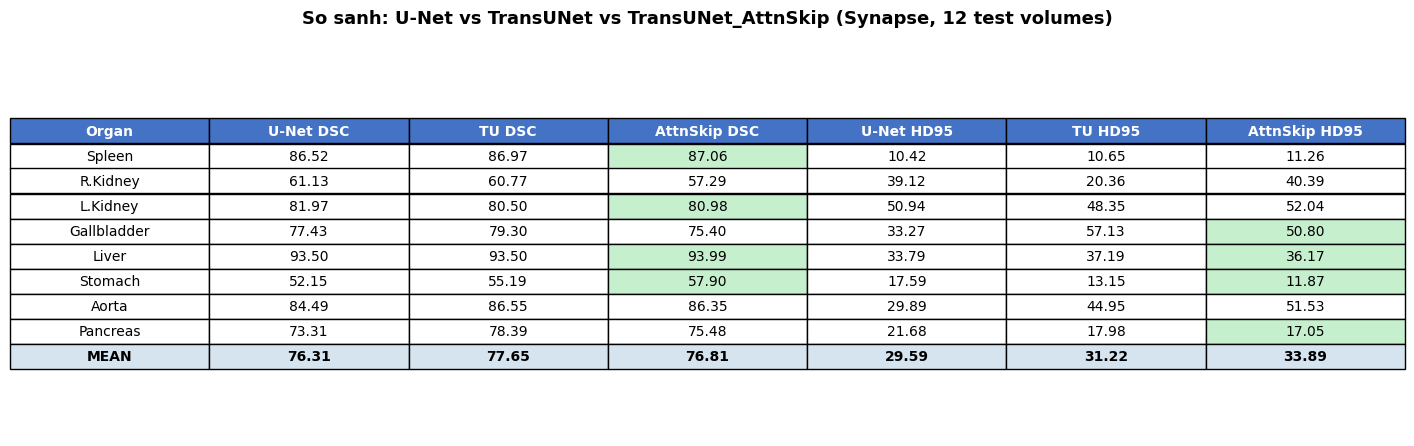

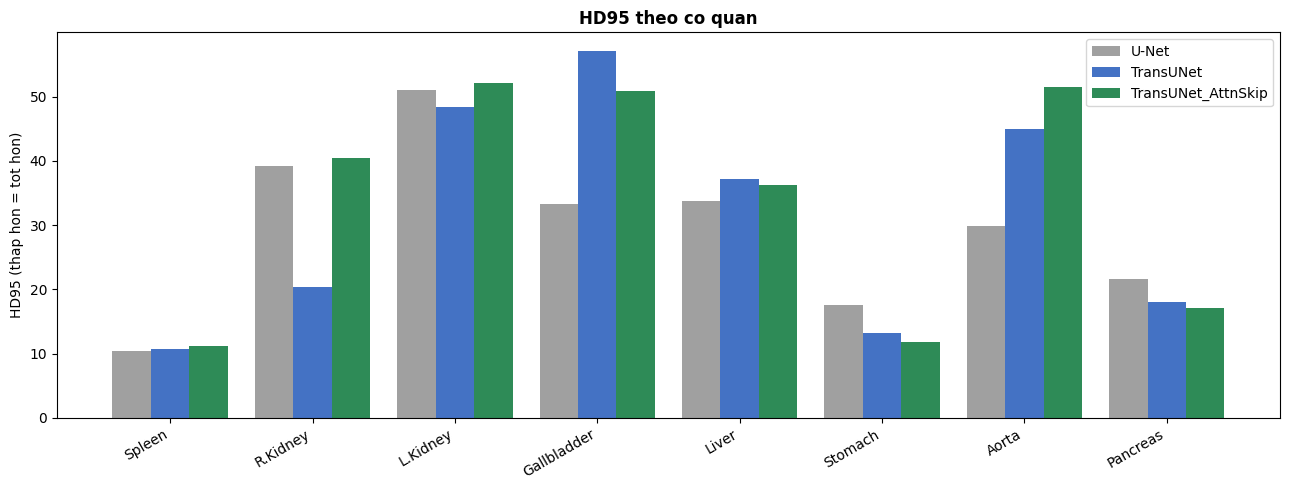

U-Net              : Mean DSC = 76.31%   Mean HD95 =  29.59
TransUNet (goc)    : Mean DSC = 77.65%   Mean HD95 =  31.22
TransUNet_AttnSkip : Mean DSC = 76.81%   Mean HD95 =  33.89
AttnSkip vs TransUNet goc:  DSC -0.84%   |   HD95 +2.67


In [8]:
import numpy as np
import matplotlib.pyplot as plt

ORGAN = ['Spleen', 'R.Kidney', 'L.Kidney', 'Gallbladder',
         'Liver', 'Stomach', 'Aorta', 'Pancreas']

# --- Baseline tu demo.ipynb (per-class, index = class Synapse 1..8) ---
tu_dice  = np.array([0.8697, 0.6077, 0.8050, 0.7930, 0.9350, 0.5519, 0.8655, 0.7839])
tu_hd95  = np.array([10.65, 20.36, 48.35, 57.13, 37.19, 13.15, 44.95, 17.98])
un_dice  = np.array([0.8652, 0.6113, 0.8197, 0.7743, 0.9350, 0.5215, 0.8449, 0.7331])
un_hd95  = np.array([10.42, 39.12, 50.94, 33.27, 33.79, 17.59, 29.89, 21.68])

# --- Ket qua AttnSkip vua train ---
m = np.load('/content/model/TU_AttnSkip_Synapse224/metrics.npy')  # (8,2): [dice, hd95]
ag_dice = m[:, 0]
ag_hd95 = m[:, 1]

# ============ BANG SO SANH ============
fig, ax = plt.subplots(figsize=(15, 5)); ax.axis('off')
cols = ['Organ', 'U-Net DSC', 'TU DSC', 'AttnSkip DSC',
        'U-Net HD95', 'TU HD95', 'AttnSkip HD95']
rows = []
for i in range(8):
    rows.append([ORGAN[i],
                 f'{un_dice[i]*100:.2f}', f'{tu_dice[i]*100:.2f}', f'{ag_dice[i]*100:.2f}',
                 f'{un_hd95[i]:.2f}', f'{tu_hd95[i]:.2f}', f'{ag_hd95[i]:.2f}'])
rows.append(['MEAN',
             f'{un_dice.mean()*100:.2f}', f'{tu_dice.mean()*100:.2f}', f'{ag_dice.mean()*100:.2f}',
             f'{un_hd95.mean():.2f}', f'{tu_hd95.mean():.2f}', f'{ag_hd95.mean():.2f}'])
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#4472C4'); tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[9, j].set_facecolor('#D6E4F0'); tbl[9, j].set_text_props(fontweight='bold')
# To xanh khi AttnSkip tot hon TransUNet goc
for i in range(8):
    if ag_dice[i] > tu_dice[i]: tbl[i+1, 3].set_facecolor('#C6EFCE')
    if ag_hd95[i] < tu_hd95[i]: tbl[i+1, 6].set_facecolor('#C6EFCE')
ax.set_title('So sanh: U-Net vs TransUNet vs TransUNet_AttnSkip (Synapse, 12 test volumes)',
             fontsize=13, fontweight='bold', pad=20)
import os; os.makedirs('/content/caitien_output', exist_ok=True)
plt.savefig('/content/caitien_output/compare_table.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO HD95 ============
x = np.arange(8); wd = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wd, un_hd95, wd, label='U-Net', color='#A0A0A0')
ax.bar(x,      tu_hd95, wd, label='TransUNet', color='#4472C4')
ax.bar(x + wd, ag_hd95, wd, label='TransUNet_AttnSkip', color='#2E8B57')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('HD95 (thap hon = tot hon)')
ax.set_title('HD95 theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/caitien_output/compare_hd95.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ TONG KET ============
print('='*64)
print(f"U-Net              : Mean DSC = {un_dice.mean()*100:5.2f}%   Mean HD95 = {un_hd95.mean():6.2f}")
print(f"TransUNet (goc)    : Mean DSC = {tu_dice.mean()*100:5.2f}%   Mean HD95 = {tu_hd95.mean():6.2f}")
print(f"TransUNet_AttnSkip : Mean DSC = {ag_dice.mean()*100:5.2f}%   Mean HD95 = {ag_hd95.mean():6.2f}")
print('='*64)
d_dsc  = (ag_dice.mean() - tu_dice.mean()) * 100
d_hd95 = ag_hd95.mean() - tu_hd95.mean()
print(f"AttnSkip vs TransUNet goc:  DSC {d_dsc:+.2f}%   |   HD95 {d_hd95:+.2f}")
print('='*64)

## 6. Trực quan hóa định tính (CT | Ground Truth | TransUNet_AttnSkip)

Vẽ overlay dự đoán của mô hình mới so với nhãn thật, cho vài lát cắt nhiều cơ quan nhất.

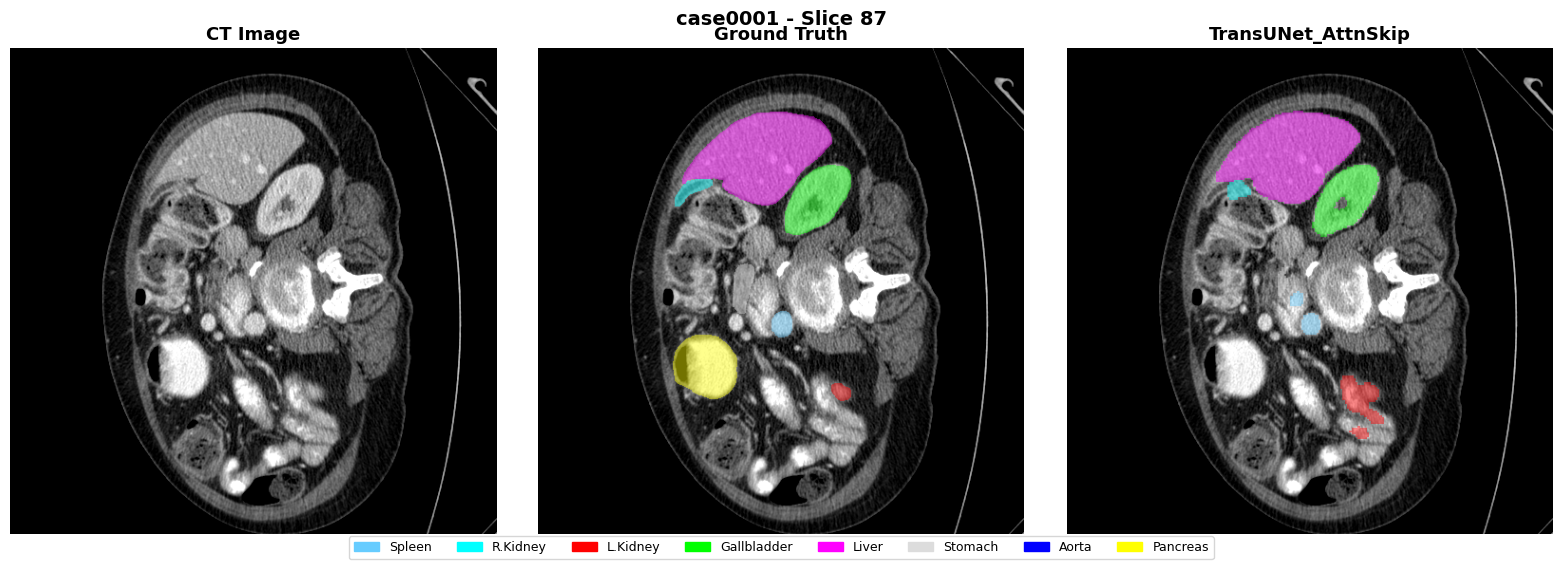

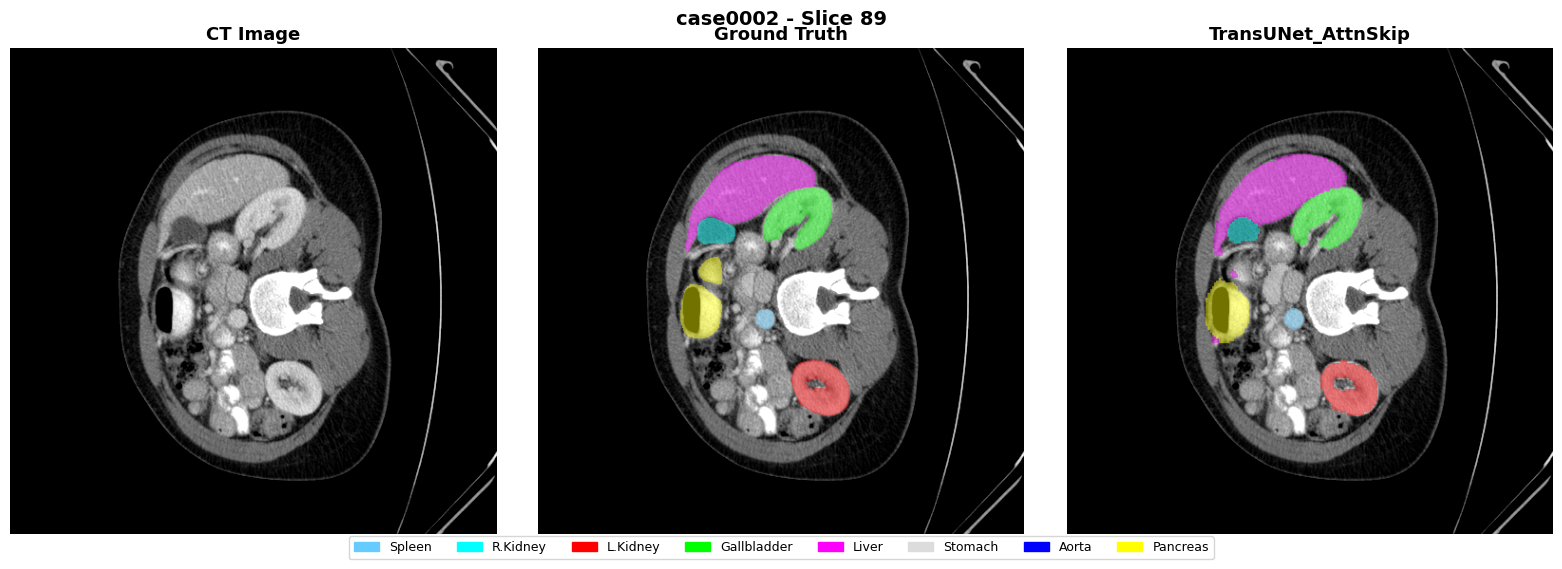

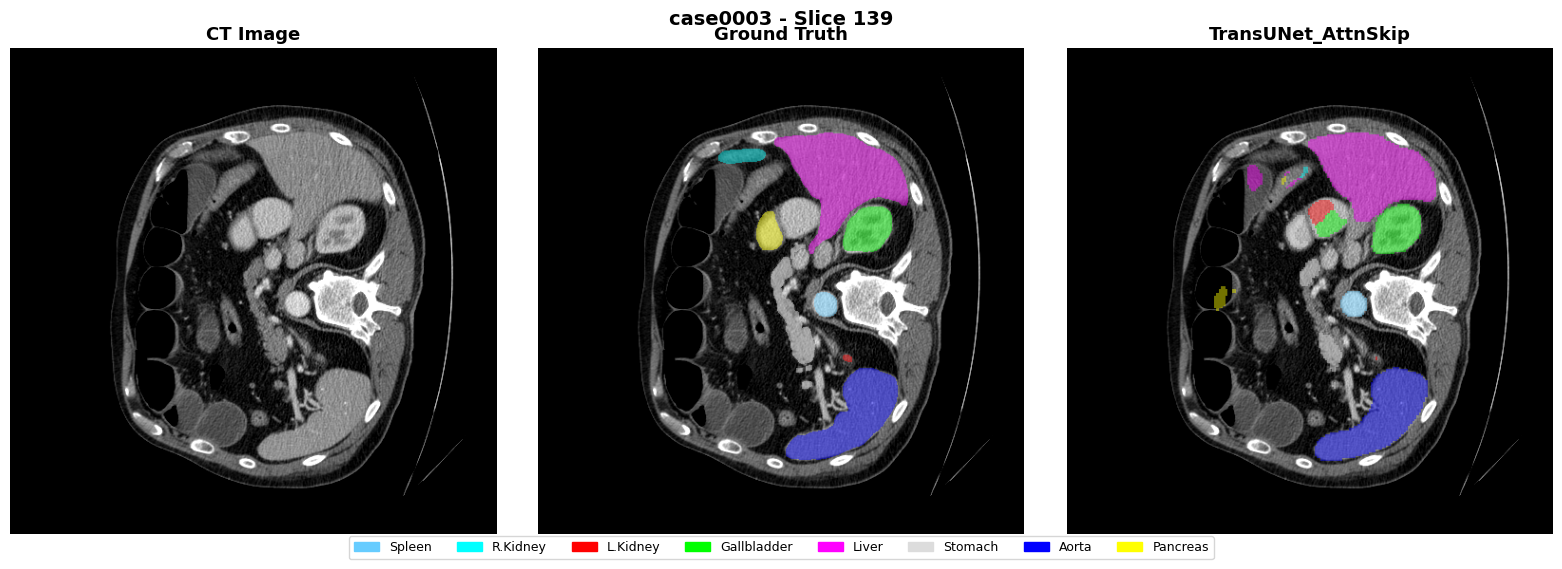

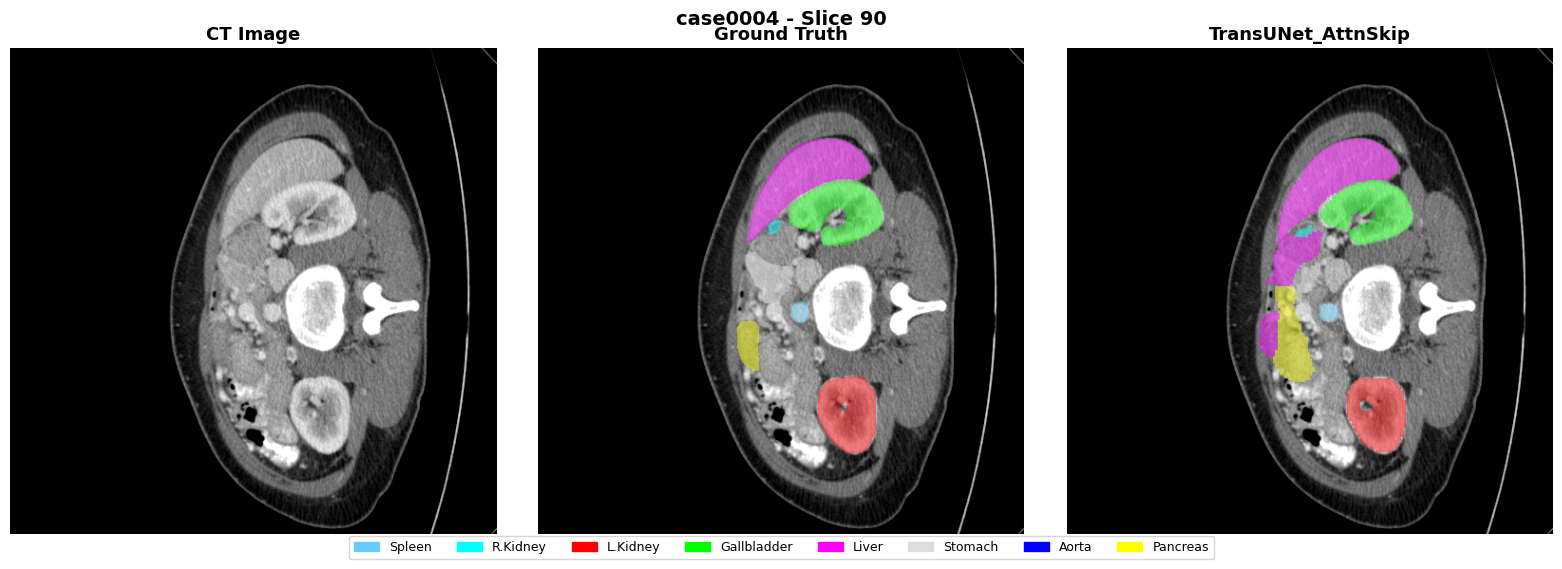

In [9]:
import os, sys, glob, h5py
import numpy as np, torch
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from scipy.ndimage import zoom

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}
CLR = np.array([[0,0,0],[102,204,255],[0,255,255],[255,0,0],[0,255,0],
                [255,0,255],[220,220,220],[0,0,255],[255,255,0]]) / 255.

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9; config_vit.n_skip = 3; config_vit.patches.grid = (14, 14)
net = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()
_ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_Synapse224/epoch_*.pth'),
               key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
net.load_state_dict(torch.load(_ckpt))
net.eval()

def predict(slc):
    h, w = slc.shape
    s = zoom(slc, (224/h, 224/w), order=3) if (h != 224 or w != 224) else slc
    with torch.no_grad():
        o = net(torch.from_numpy(s).unsqueeze(0).unsqueeze(0).float().cuda())
        o = torch.argmax(torch.softmax(o, 1), 1).squeeze(0).cpu().numpy()
    return zoom(o, (h/224, w/224), order=0).astype(int) if (h != 224 or w != 224) else o.astype(int)

def overlay(img, lbl, a=0.45):
    im = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([im]*3, -1).copy()
    for c in range(1, 9):
        m = lbl == c
        if m.any():
            for ch in range(3):
                rgb[:, :, ch][m] = (1-a)*rgb[:, :, ch][m] + a*CLR[c][ch]
    return np.clip(rgb, 0, 1)

out_dir = '/content/caitien_output'; os.makedirs(out_dir, exist_ok=True)
test_dir = '/content/data/Synapse/test_vol_h5'
cases = sorted([f.replace('.npy.h5', '') for f in os.listdir(test_dir)])[:4]

for case in cases:
    data = h5py.File(os.path.join(test_dir, f'{case}.npy.h5'), 'r')
    imgs, lbls = data['image'][:], data['label'][:]
    n = imgs.shape[0]
    si = sorted(range(n), key=lambda s: -len(np.unique(lbls[s])))[0]
    gt = lbls[si].astype(int)
    pred = predict(imgs[si])
    fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
    im_n = (imgs[si] - imgs[si].min()) / (imgs[si].max() - imgs[si].min() + 1e-8)
    ax[0].imshow(im_n, cmap='gray'); ax[0].set_title('CT Image', fontsize=13, fontweight='bold')
    ax[1].imshow(overlay(imgs[si], gt)); ax[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
    ax[2].imshow(overlay(imgs[si], pred)); ax[2].set_title('TransUNet_AttnSkip', fontsize=13, fontweight='bold')
    for a_ in ax: a_.axis('off')
    patches = [mpatches.Patch(color=CLR[i], label=ORGAN[i]) for i in range(1, 9)]
    fig.legend(handles=patches, loc='lower center', ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'{case} - Slice {si}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/{case}_s{si}.png', dpi=150, bbox_inches='tight'); plt.show()

In [10]:
# Dong goi ket qua de tai ve
!zip -r /content/caitien_output.zip /content/caitien_output/
from google.colab import files
files.download('/content/caitien_output.zip')

  adding: content/caitien_output/ (stored 0%)
  adding: content/caitien_output/compare_hd95.png (deflated 22%)
  adding: content/caitien_output/case0003_s139.png (deflated 3%)
  adding: content/caitien_output/compare_table.png (deflated 13%)
  adding: content/caitien_output/case0004_s90.png (deflated 4%)
  adding: content/caitien_output/case0002_s89.png (deflated 4%)
  adding: content/caitien_output/case0001_s87.png (deflated 3%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>